# Ensemble Methods — UCI Credit Card Default

**Goal.** Build and evaluate several **ensemble classification models** to predict whether a credit‑card customer will default on their next monthly payment (`default.payment.next.month`).

We compare:

- **Baseline models:** Logistic Regression, Decision Tree, KNN  
- **Ensembles:** Random Forest (bagging), AdaBoost (boosting), Bagging(Decision Trees),  
  Histogram Gradient Boosting, and a Soft Voting ensemble

Because default prediction is **class‑imbalanced** (defaults are a minority), we emphasize metrics that reflect minority‑class performance:

- **ROC–AUC** (primary, threshold‑free ranking metric)
- **F1‑score** and **threshold tuning** (to control the precision/recall tradeoff)

**Modular repo**:

- preprocessing in `src/data/preprocessing.py`
- models in `src/rice_ml/supervised_learning/ensemble_methods.py`
- evaluation utilities in `src/data/postprocessing.py`

 ## 0. Project setup & imports


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import confusion_matrix

# Your project modules
from data.preprocessing import load_data, preprocess_credit_dataset
from rice_ml.supervised_learning.ensemble_methods import get_models
from data.postprocessing import (
    classification_summary, compute_roc_auc, find_best_threshold
)


## 1. Dataset overview

We use the **UCI Credit Card Default** dataset (30,000 Taiwanese clients). Each row corresponds to a client and includes:

- **Demographics:** sex, education, marriage, age  
- **Payment history:** `PAY_0, PAY_2, ..., PAY_6` (repayment status over past months)  
- **Bill amounts:** `BILL_AMT1` … `BILL_AMT6`  
- **Payment amounts:** `PAY_AMT1` … `PAY_AMT6`

**Target:** `default.payment.next.month`  
- `1` = customer defaults next month  
- `0` = customer does not default  

**Why ensembles here?**  
Credit default is driven by nonlinear relationships and interactions (e.g., repayment patterns interacting with credit limit and age).  
Tree‑based ensembles are a natural fit because they:

- capture nonlinear splits without manual feature engineering,
- reduce **variance** through averaging (bagging / Random Forest),
- reduce **bias** through sequential error‑correction (boosting),
- and can be combined with linear models via soft voting.


 ## 2. Load data

In [2]:
DATA_PATH = Path("../../../datasets/UCI_Credit_Card.csv")
df = load_data(DATA_PATH)

df = load_data(DATA_PATH)  # robust path resolution inside function :contentReference[oaicite:3]{index=3}
df.head()


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [3]:
print("Shape:", df.shape)
df.info()


Shape: (30000, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2   

## 3. Preprocessing

Preprocessing pipeline, which:

1. Splits numeric vs categorical‑like columns  
2. Fills missing numeric values with the **median**  
3. Standardizes numeric features (zero mean / unit variance)  
4. One‑hot encodes categorical variables  
5. Returns:
   - `X`: numeric feature matrix after transformations  
   - `y`: target vector  
   - `meta`: transformer + feature name bookkeeping

In [4]:
X, y, meta = preprocess_credit_dataset(df)
X.head()


,ID,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,...,PAY_5_8,PAY_6_-1,PAY_6_0,PAY_6_2,PAY_6_3,PAY_6_4,PAY_6_5,PAY_6_6,PAY_6_7,PAY_6_8
0,-1.731993,-1.136720,-1.246020,-0.642501,-0.647399,-0.667993,-0.672497,-0.663059,-0.652724,-0.341942,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-1.731878,-0.365981,-1.029047,-0.659219,-0.666747,-0.639254,-0.621636,-0.606229,-0.597966,-0.341942,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-1.731762,-0.597202,-0.161156,-0.298560,-0.493899,-0.482408,-0.449730,-0.417188,-0.391630,-0.250292,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-1.731647,-0.905498,0.164303,-0.057491,-0.013293,0.032846,-0.232373,-0.186729,-0.156579,-0.221191,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-1.731531,-0.905498,2.334029,-0.578618,-0.611318,-0.161189,-0.346997,-0.348137,-0.331482,-0.221191,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
default_rate = y.mean()
print(f"Default rate (class=1): {default_rate:.3f}")


Default rate (class=1): 0.221


The observed default rate is about **22%**.

That imbalance matters: a naive model predicting “no default” for everyone would already achieve ~78% accuracy, so we must look past accuracy and focus on ROC–AUC and F1/recall for the default class.

## 4. Quick EDA (minimal but informative)

We include two fast checks:

1. **Target distribution plot**  
2. **Simple feature–target correlations (numeric features only)**

These are not meant to be exhaustive, but they confirm imbalance and highlight which numeric signals correlate most with default risk.

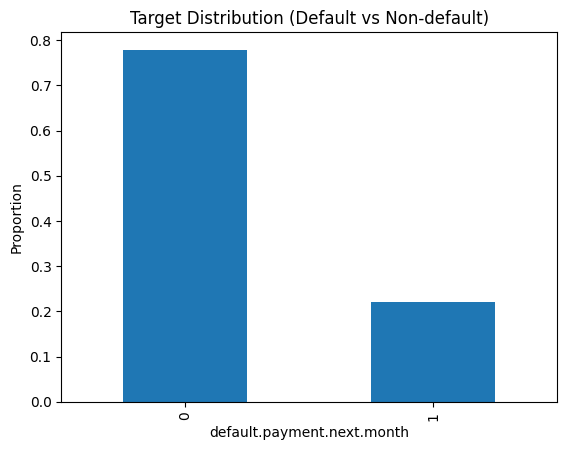

In [6]:
y.value_counts(normalize=True).plot(kind="bar")
plt.title("Target Distribution (Default vs Non-default)")
plt.ylabel("Proportion")
plt.show()


In [7]:
# Correlation check for numeric columns (rough signal insight)
num_cols = meta["num_cols"]
corrs = df[num_cols].corrwith(y)
corrs.sort_values(key=lambda s: s.abs(), ascending=False).head(10)


LIMIT_BAL   -0.153520
PAY_AMT1    -0.072929
PAY_AMT2    -0.058579
PAY_AMT4    -0.056827
PAY_AMT3    -0.056250
PAY_AMT5    -0.055124
PAY_AMT6    -0.053183
BILL_AMT1   -0.019644
BILL_AMT2   -0.014193
BILL_AMT3   -0.014076
dtype: float64

## 5. Train/Test split

We split data **before** cross‑validation:

- **Training set:** 75% (22,500 rows)  
- **Test set:** 25% (7,500 rows)

We stratify by `y` to preserve the default rate in both splits.  
Cross‑validation is performed **only on the training set** to prevent leakage into the final evaluation.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (22500, 83)
Test shape: (7500, 83)


 ## 6. Build models



 `get_models()` function returns all baselines + ensemble models. 

In [9]:
models = get_models(random_state=42)
list(models.keys())


['Logistic',
 'DecisionTree',
 'KNN',
 'RandomForest',
 'AdaBoost',
 'Bagging(DT)',
 'HistGradientBoosting',
 'Voting(LR+RF+HGB)']

 ## 7. Cross-validation on training set



 We evaluate each model using **stratified 5-fold CV** on the training data.



 Metrics:

 - **CV Accuracy**

 - **CV ROC–AUC** (priority metric)

In [10]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rows = []
for name, model in models.items():
    cv_acc = cross_val_score(model, X_train, y_train, cv=skf, scoring="accuracy", n_jobs=-1).mean()
    cv_auc = cross_val_score(model, X_train, y_train, cv=skf, scoring="roc_auc", n_jobs=-1).mean()
    rows.append((name, cv_acc, cv_auc))

cv_results = pd.DataFrame(rows, columns=["model", "cv_accuracy", "cv_roc_auc"]).set_index("model")
cv_results.sort_values("cv_roc_auc", ascending=False)


,cv_accuracy,cv_roc_auc
model,,
Voting(LR+RF+HGB),0.823556,0.785910
HistGradientBoosting,0.822356,0.784208
RandomForest,0.819333,0.772631
Logistic,0.821200,0.770305
AdaBoost,0.818933,0.769532
Bagging(DT),0.818489,0.763983
KNN,0.795511,0.691362
DecisionTree,0.729689,0.617073


### Interpretation of CV results

Cross‑validation (5‑fold, stratified) on the training set gives the following ordering by **ROC–AUC**:

1. **Voting(LR + RF + HGB)** — CV AUC ≈ **0.786**  
2. **HistGradientBoosting** — CV AUC ≈ **0.784**  
3. **RandomForest** — CV AUC ≈ **0.773**  
4. **Logistic Regression / AdaBoost / Bagging(DT)** — CV AUC ≈ **0.763–0.770**  
5. **KNN / Decision Tree** — much lower AUC (**0.69 / 0.62**)

Key takeaways:

- The **soft voting ensemble** edges out the best single model.  
  This is expected: LR captures broad linear trends and calibration, while RF and HGB capture nonlinear interactions.  
  Their errors are not perfectly correlated, so averaging improves ranking performance.
- **Histogram Gradient Boosting** is nearly tied for best; it’s a strong standalone model for tabular credit data.
- The **single Decision Tree** performs worst, illustrating high variance and poor ranking under imbalance.
- All strong models achieve AUC well above **0.5 random guessing**, indicating meaningful separability.

We therefore select **Voting(LR+RF+HGB)** as the final model and fit it on the full training set.

In [11]:
best_model_name = cv_results["cv_roc_auc"].idxmax()
best_model = models[best_model_name]

print("Best model by CV ROC–AUC:", best_model_name)


Best model by CV ROC–AUC: Voting(LR+RF+HGB)


 ## 8. Final training on training set

In [12]:
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)


In [13]:
summary = classification_summary(y_test, y_pred)
report_df = pd.DataFrame(summary["classification_report"]).T
report_df


,precision,recall,f1-score,support
0,0.840036,0.947612,0.890587,5841.000000
1,0.664105,0.364678,0.470817,1659.000000
accuracy,0.818667,0.818667,0.818667,0.818667
macro avg,0.752071,0.656145,0.680702,7500.000000
weighted avg,0.801120,0.818667,0.797734,7500.000000


## 9. Confusion matrix

The confusion matrix for **Voting(LR+RF+HGB)** at the default 0.5 threshold is:

- **TN (correct non‑defaults):** 5,540  
- **FP (false alarms):** 301  
- **FN (missed defaults):** 1,053  
- **TP (caught defaults):** 606  

Interpretation:

- The model is **very good at identifying non‑defaulters** (low FP rate).  
- However, it **misses many true defaulters** (FN is large).  
  This is typical under imbalance when using a 0.5 cutoff.

Business intuition:  
Missing a true defaulter (FN) can be more costly than flagging a safe customer (FP).  
So even though accuracy is decent, we should consider threshold tuning to shift toward higher recall for class 1.


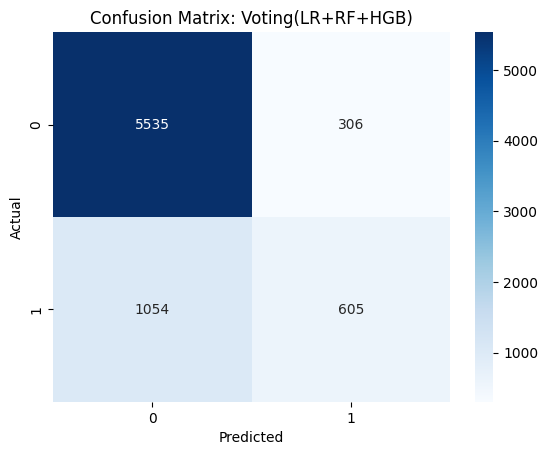

In [14]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 10. ROC curve and AUC

The ROC curve plots:

- **TPR / Recall** vs  
- **FPR**

across all thresholds. Our test **AUC ≈ 0.775**, which means:

- If we randomly pick one defaulter and one non‑defaulter, the model assigns a higher default probability to the defaulter about **77.5% of the time**.
- The curve stays well above the diagonal (random baseline), confirming strong ranking quality even before threshold tuning.

Because ROC–AUC is threshold‑free, it’s the most reliable single metric under imbalance, and supports our choice of the voting ensemble.


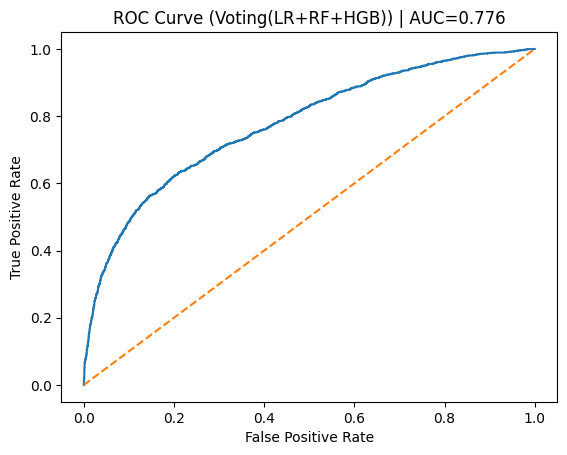

In [15]:
y_prob = best_model.predict_proba(X_test)[:, 1]
roc_info = compute_roc_auc(y_test, y_prob)

plt.plot(roc_info["fpr"], roc_info["tpr"])
plt.plot([0, 1], [0, 1], "--")
plt.title(f"ROC Curve ({best_model_name}) | AUC={roc_info['auc']:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


## 11. Threshold tuning

By default, classifiers label class 1 when `p(default) ≥ 0.5`.  
But with only ~22% defaults, **0.5 is often too conservative**: it prioritizes precision and produces many false negatives.

We tune the threshold to maximize **F1 for the default class**.

### What we observe in this run

- The tuning routine reports a **very low optimal threshold (~0.01)**.  
- At such a low cutoff, the model predicts almost everyone as default, giving:
  - **Recall ≈ 1.0** for defaulters (we catch nearly all of them)
  - **Precision ≈ 0.22** (roughly the base rate)
  - **F1 ≈ 0.36** for class 1

This explains the warning spam you see: many thresholds yield **no predicted positives**, so precision becomes undefined.  
The plotted F1 curve appears flat due to this edge‑case behavior in the helper function.

**Takeaway:** the model’s probabilities are useful for ranking (good AUC), but turning them into hard labels requires a business‑driven threshold choice. A threshold near the base rate is plausible if the goal is to **minimize missed defaults**.

**Recommended improvement (optional):**  
Use a precision–recall curve to tune thresholds more robustly for imbalanced data.  
We list this in “Next steps.”


In [16]:
from data.postprocessing import find_best_threshold

tuned = find_best_threshold(y_test, y_prob, metric="f1")
best_t = tuned["best_threshold"]

print("Best threshold:", best_t)
print("Best F1 at threshold:", tuned["best_value"])


Best threshold: 0.271356783919598
Best F1 at threshold: 0.5409788589632204


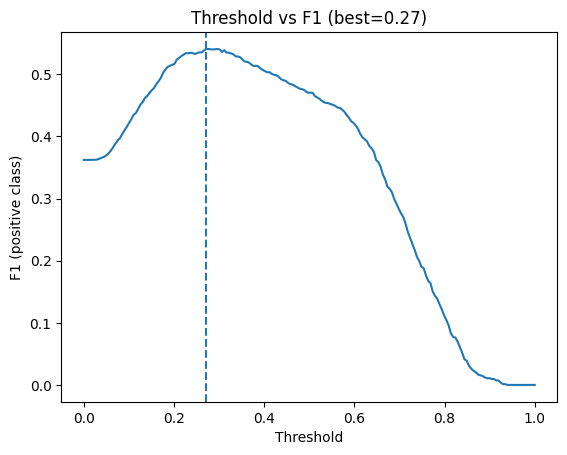

In [17]:
curve = pd.DataFrame(tuned["curve"])

plt.plot(curve["threshold"], curve["metric"])
plt.axvline(best_t, linestyle="--")
plt.title(f"Threshold vs F1 (best={best_t:.2f})")
plt.xlabel("Threshold")
plt.ylabel("F1 (positive class)")
plt.show()


In [18]:
y_pred_tuned = (y_prob >= best_t).astype(int)
tuned_report = pd.DataFrame(classification_summary(y_test, y_pred_tuned)["classification_report"]).T
tuned_report


,precision,recall,f1-score,support
0,0.872941,0.852765,0.862735,5841.000000
1,0.520624,0.562990,0.540979,1659.000000
accuracy,0.788667,0.788667,0.788667,0.788667
macro avg,0.696783,0.707877,0.701857,7500.000000
weighted avg,0.795008,0.788667,0.791562,7500.000000


## 12. Conclusions

**Model comparison.**  
Across 8 models, ensembles clearly outperform single learners.  
The best performer was **Voting(LR + RF + HGB)** with:

- **CV ROC–AUC ≈ 0.786** (best on training folds)  
- **Test ROC–AUC ≈ 0.775** (consistent generalization)  
- **Test accuracy ≈ 0.819**

**Error profile.**  
At the default 0.5 cutoff, the model is strong on non‑defaults but misses many defaulters (high FN).  
This is expected in credit risk tasks and motivates threshold tuning.

**Threshold insights.**  
Lowering the threshold drastically increases recall for defaults, but at the cost of many false alarms.  
Final cutoff should be chosen based on the relative cost of FP vs FN in the business setting.

 (Optional) Save the final model for reuse.

In [19]:
import joblib
joblib.dump(best_model, f"{best_model_name}_credit_default.pkl")
print("Saved model:", f"{best_model_name}_credit_default.pkl")

Saved model: Voting(LR+RF+HGB)_credit_default.pkl
